In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/My Drive/Group 10 Project/data/eegmmidb/')[:5])

DATA_PATH = "/content/drive/My Drive/Group 10 Project/data/eegmmidb/"

Mounted at /content/drive
['64_channel_sharbrough-old.png', 'SHA256SUMS.txt', 'ANNOTATORS', 'RECORDS', '64_channel_sharbrough.pdf']


saved subject files were created with different epoch lengths. For PCA, everything must have the same feature dimensions, so we need to standardize at load time.

scan all saved subject files

find the most common shape for each condition

keep only arrays matching that shape

skip the mismatches and log them

# **important note**

there exists 3 subjects with incorrect epoching. We have removed these 3 subject in subsequent analysis. (I believe that their epoch lengths were messed up do to a previous run I had initiated erroneously)

loading cell

In [ ]:
# ---------------------------------------------------------
# Load processed epoch dataset for PCA analysis
# Excludes subjects with incorrect epoch length
# ---------------------------------------------------------

from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd

base_dir = Path("/content/drive/My Drive/Group 10 Project/data/processed_subject_epochs")

subject_dirs = sorted([
    d for d in base_dir.iterdir()
    if d.is_dir() and d.name.startswith("S")
])

print("Subjects detected:", len(subject_dirs))

# Subjects with incorrect epoch length
bad_subjects = {"S088", "S092", "S100"}

condition_data = defaultdict(list)
metadata_all = []

kept_subjects = []
skipped_subjects = []

for subj_dir in subject_dirs:

    if subj_dir.name in bad_subjects:
        skipped_subjects.append(subj_dir.name)
        continue

    npz_path = subj_dir / "epochs.npz"
    metadata_path = subj_dir / "metadata.csv"

    if not npz_path.exists():
        continue

    subj_npz = np.load(npz_path)

    for cond in subj_npz.files:
        condition_data[cond].append(subj_npz[cond])

    if metadata_path.exists():
        metadata_all.append(pd.read_csv(metadata_path))

    kept_subjects.append(subj_dir.name)

print("Subjects kept:", len(kept_subjects))
print("Subjects excluded:", skipped_subjects)

# ---------------------------------------------------------
# Concatenate safely
# ---------------------------------------------------------

condition_arrays = {}

for cond, arrays in condition_data.items():
    condition_arrays[cond] = np.concatenate(arrays, axis=0)

print("\nCondition dataset shapes:")

for cond in sorted(condition_arrays.keys()):
    print(cond, condition_arrays[cond].shape)

# Combine metadata
metadata_all = pd.concat(metadata_all, ignore_index=True)

print("\nMetadata rows:", len(metadata_all))

Subjects detected: 109
Subjects kept: 106
Subjects excluded: ['S088', 'S092', 'S100']

Condition dataset shapes:
both_feet (4778, 64, 401)
both_fists (4751, 64, 401)
left_fist (4801, 64, 401)
rest (17803, 64, 401)
right_fist (4744, 64, 401)

Metadata rows: 36877


turns the saved EEG tensors into some PCA ready matrices

In [ ]:
# ---------------------------------------------------------
# Prepare left_fist and right_fist matrices for PCA
# ---------------------------------------------------------

from sklearn.preprocessing import StandardScaler

# Select the two conditions for the first PCA experiment
left_epochs = condition_arrays["left_fist"]      # shape: (n_epochs, 64, 401)
right_epochs = condition_arrays["right_fist"]    # shape: (n_epochs, 64, 401)

print("Original shapes:")
print("left_fist:", left_epochs.shape)
print("right_fist:", right_epochs.shape)

# Flatten each epoch into one feature vector
X_left = left_epochs.reshape(left_epochs.shape[0], -1)
X_right = right_epochs.reshape(right_epochs.shape[0], -1)

print("\nFlattened shapes:")
print("X_left:", X_left.shape)
print("X_right:", X_right.shape)

# Standardize each feature so PCA is not dominated by scale
scaler_left = StandardScaler()
scaler_right = StandardScaler()

X_left_scaled = scaler_left.fit_transform(X_left)
X_right_scaled = scaler_right.fit_transform(X_right)

print("\nScaled matrices ready for PCA:")
print("X_left_scaled:", X_left_scaled.shape)
print("X_right_scaled:", X_right_scaled.shape)

Original shapes:
left_fist: (4801, 64, 401)
right_fist: (4744, 64, 401)

Flattened shapes:
X_left: (4801, 25664)
X_right: (4744, 25664)

Scaled matrices ready for PCA:
X_left_scaled: (4801, 25664)
X_right_scaled: (4744, 25664)


run the PCA separately on the left_fist and then right_fist, then inspect all the explained variance

Variance explained by first 10 components:

Left fist:
[0.08726546 0.05307792 0.05035219 0.03903911 0.03239665 0.02996294
 0.02368106 0.02068815 0.01985388 0.01812477]

Right fist:
[0.08812395 0.05359573 0.04950007 0.03974736 0.03151606 0.02799932
 0.02288021 0.02198353 0.019995   0.0175024 ]


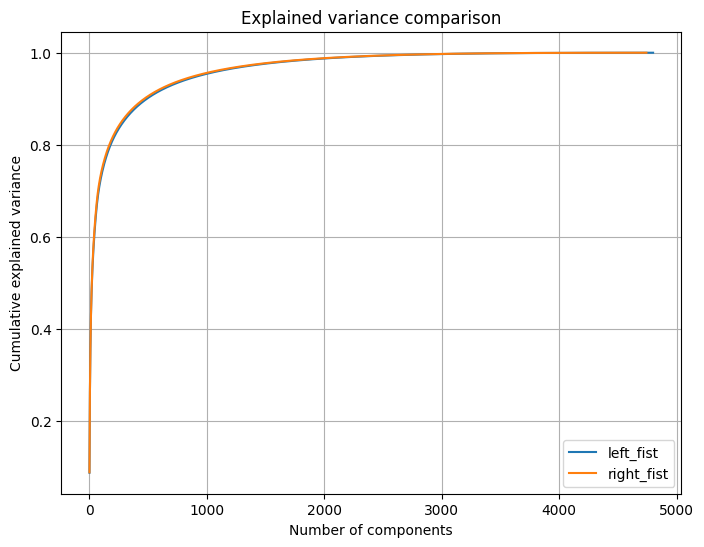

In [ ]:
# ---------------------------------------------------------
# Run PCA on left_fist and right_fist conditions
# ---------------------------------------------------------

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA models
pca_left = PCA()
pca_right = PCA()

pca_left.fit(X_left_scaled)
pca_right.fit(X_right_scaled)

# Extract explained variance ratios
ev_left = pca_left.explained_variance_ratio_
ev_right = pca_right.explained_variance_ratio_

# Cumulative explained variance
cum_left = np.cumsum(ev_left)
cum_right = np.cumsum(ev_right)

print("Variance explained by first 10 components:\n")

print("Left fist:")
print(ev_left[:10])

print("\nRight fist:")
print(ev_right[:10])


# ---------------------------------------------------------
# Plot cumulative explained variance
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

plt.plot(cum_left, label="left_fist")
plt.plot(cum_right, label="right_fist")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

plt.title("Explained variance comparison")

plt.legend()
plt.grid(True)

plt.show()

compute principal angles between the PCA subspaces

In [ ]:
# ---------------------------------------------------------
# Compare PCA subspaces using principal angles
# ---------------------------------------------------------

from scipy.linalg import subspace_angles
import numpy as np

# choose number of components defining the subspace
k = 20

# extract top-k eigenvectors
U_left = pca_left.components_[:k].T
U_right = pca_right.components_[:k].T

# compute principal angles
angles = subspace_angles(U_left, U_right)

print("Principal angles (degrees):")
print(np.degrees(angles))

Principal angles (degrees):
[81.65211   36.53734   32.65638   20.966152  19.043352  15.876761
 14.593424  12.302131  11.402836  10.386843   9.454661   9.130465
  8.634066   7.6815248  7.2508497  6.6645846  5.8940544  4.8410354
  4.5578623  3.7423522]


compute how subspace similarity changes as dimension increases

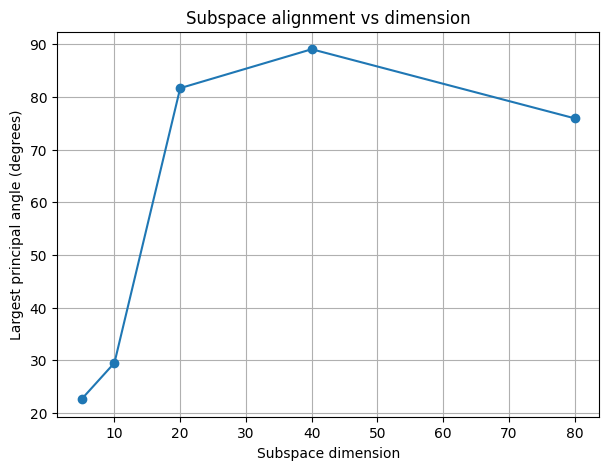

In [ ]:
# ---------------------------------------------------------
# Subspace similarity as a function of dimension
# ---------------------------------------------------------

from scipy.linalg import subspace_angles
import numpy as np
import matplotlib.pyplot as plt

dims = [5, 10, 20, 40, 80]

largest_angles = []

for k in dims:

    U_left = pca_left.components_[:k].T
    U_right = pca_right.components_[:k].T

    angles = subspace_angles(U_left, U_right)

    largest_angles.append(np.degrees(angles[0]))


plt.figure(figsize=(7,5))

plt.plot(dims, largest_angles, marker="o")

plt.xlabel("Subspace dimension")
plt.ylabel("Largest principal angle (degrees)")
plt.title("Subspace alignment vs dimension")

plt.grid(True)
plt.show()

repeating the same analysis but now comparing a movement condition vs the rest.

In [ ]:
# ---------------------------------------------------------
# Prepare left_fist vs rest matrices for PCA
# ---------------------------------------------------------

from sklearn.preprocessing import StandardScaler

left_epochs = condition_arrays["left_fist"]
rest_epochs = condition_arrays["rest"]

print("Original shapes:")
print("left_fist:", left_epochs.shape)
print("rest:", rest_epochs.shape)

# flatten epochs
X_left = left_epochs.reshape(left_epochs.shape[0], -1)
X_rest = rest_epochs.reshape(rest_epochs.shape[0], -1)

print("\nFlattened shapes:")
print("X_left:", X_left.shape)
print("X_rest:", X_rest.shape)

# standardize
scaler_left = StandardScaler()
scaler_rest = StandardScaler()

X_left_scaled = scaler_left.fit_transform(X_left)
X_rest_scaled = scaler_rest.fit_transform(X_rest)

print("\nScaled matrices ready for PCA:")
print("X_left_scaled:", X_left_scaled.shape)
print("X_rest_scaled:", X_rest_scaled.shape)

Original shapes:
left_fist: (4801, 64, 401)
rest: (17803, 64, 401)

Flattened shapes:
X_left: (4801, 25664)
X_rest: (17803, 25664)


crashed after the ram died out, maybe worth having a bunch of different notebooks that each do a different task.